In [1]:
import matplotlib.pyplot as plt
import numpy as np

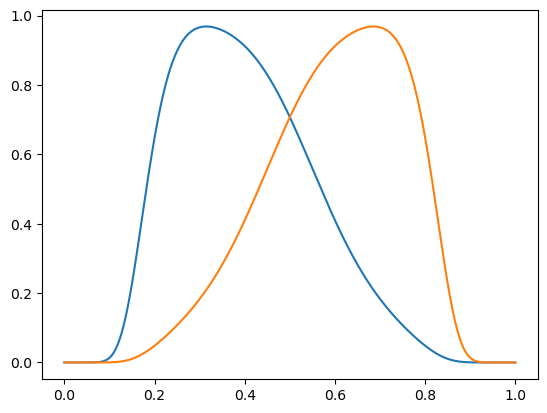

In [ ]:
awg_sampling_rate = 1
t_length = 1
length_repump = t_length * awg_sampling_rate
t_repump, t_repump_step = np.linspace(0, length_repump, int(length_repump * 1000), retstep=True)

a = 10
n = 4
c = t_length / 3


def stokes_shape_plot(t, T):  # noqa: N803
    return np.exp(-(((t - (T / 2)) / c) ** (2 * n))) * np.cos(
        np.pi / 2 * (1 / (1 + np.exp((-a * (t - T / 2)) / T)))
    )


def shape_pump_plot(t, T):  # noqa: N803
    return np.exp(-(((t - (T / 2)) / c) ** (2 * n))) * np.sin(
        np.pi / 2 * (1 / (1 + np.exp((-a * (t - T / 2)) / T)))
    )


plt.plot(t_repump, stokes_shape_plot(t_repump, length_repump))
plt.plot(t_repump, shape_pump_plot(t_repump, length_repump))
plt.show()

In [3]:
def tophat(num_samples, ramp_samples=5):
    if num_samples < 2 * ramp_samples:
        raise ValueError("num_samples must be at least twice ramp_samples.")

    tophat = np.ones(num_samples)

    # Create the ramp using a half-cosine window
    ramp_up = 0.5 * (1 - np.cos(np.pi * np.arange(ramp_samples) / ramp_samples))
    ramp_down = ramp_up[::-1]

    # Apply ramps
    tophat[:ramp_samples] = ramp_up
    tophat[-ramp_samples:] = ramp_down

    return tophat

In [ ]:
from pathlib import Path


def export_to_csv(array, scale, filepath, filename):
    full_path = None
    try:
        full_path = Path(filepath) / filename

        rescaled_arr = np.zeros(len(array))
        for i, el in enumerate(array):
            if abs(el) < 10 ** (-9):
                rescaled_arr[i] = 0
            else:
                rescaled_arr[i] = scale * array[i]

        np.savetxt(full_path, rescaled_arr, delimiter=",", newline=",", fmt="%.10f")
        # Remove trailing comma from the file
        with full_path.open("r+") as f:
            f.seek(0, 2)  # Move the cursor to the end of the file
            f.seek(f.tell() - 1, 0)  # Move one character back from the end
            if f.read(1) == ",":  # Check if the last character is a comma
                f.seek(f.tell() - 1, 0)  # Move one character back from the end again
                f.truncate()  # Remove the trailing comma
        # Append a newline at the end of the file
        with full_path.open("a") as f:
            f.write("\n")

        print(f"Data successfully exported to {full_path}")
    except Exception as e:
        print(f"Error exporting data to {full_path}: {e}")

In [6]:
scale_list = [1]
pulse_lens = [200]

for scale in scale_list:
    for pulse_len in pulse_lens:
        export_to_csv(tophat(pulse_len), scale, "tophat", f"tophat_{int(pulse_len)}ns_{scale}.csv")

Data successfully exported to tophat/tophat_200ns_1.csv
